### Popular Activation Funcitons
- Sigmoid
- tanh
- ReLu
---

### Why we want to use them

In a Deep Neural Network (DNN), the primary goal of using activation functions like **Sigmoid**, **Tanh**, and **ReLU** is to introduce **non-linearity** into the model.

Without these functions, no matter how many layers you add, the entire network would behave like a single linear regression model (a sequence of linear operations is still just one linear operation). Non-linearity allows the network to learn complex patterns, such as curves, shapes, and intricate relationships in data.

Here is a breakdown of the specific goals and use cases for each:

---

### 1. Sigmoid Activation Function
**Formula:** $\sigma(x) = \frac{1}{1 + e^{-x}}$
**Output Range:** $(0, 1)$

*   **Primary Goal:** **Probability Estimation.** Because the output is squeezed between 0 and 1, it is perfect for representing a probability (e.g., "There is an 85% chance this image is a cat").
*   **Best Use Case:** The **Output Layer** of a binary classification model.
*   **The Downside:** It suffers from the **Vanishing Gradient Problem**. When inputs are very large or very small, the gradient (slope) becomes almost zero, meaning the network stops learning during backpropagation.

### 2. Tanh (Hyperbolic Tangent)
**Formula:** $\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$
**Output Range:** $(-1, 1)$

*   **Primary Goal:** **Zero-Centered Data.** Unlike Sigmoid, Tanh is centered around zero. This means the mean of the activations is closer to zero, which makes the optimization process (gradient descent) much faster and more stable because it prevents "zig-zagging" during weight updates.
*   **Best Use Case:** Hidden layers in shallow networks or specific types of Recurrent Neural Networks (RNNs).
*   **The Downside:** Like Sigmoid, it still suffers from the **Vanishing Gradient Problem** when inputs are extreme.

### 3. ReLU (Rectified Linear Unit)
**Formula:** $f(x) = \max(0, x)$
**Output Range:** $[0, \infty)$

*   **Primary Goal:** **Computational Efficiency and Sparsity.** 
    1.  **Efficiency:** It is extremely easy to calculate (just a threshold at zero), making training much faster than exponential functions like Sigmoid/Tanh.
    2.  **Sparsity:** It turns off neurons that receive negative input (output becomes 0). This creates "sparse" representations, meaning only the most important neurons are active, which helps the model generalize better.
    3.  **Mitigating Vanishing Gradients:** For all positive inputs, the gradient is always $1$. This allows gradients to flow through deep layers without shrinking to zero.
*   **Best Use Case:** The **Hidden Layers** of almost all modern Deep Neural Networks (CNNs, Transformers, etc.).
*   **The Downside:** It can suffer from the **"Dying ReLU" problem**, where neurons get stuck in the negative zone and always output 0, effectively "dying" and contributing nothing to the learning process.

---

### Summary Comparison Table

| Feature | Sigmoid | Tanh | ReLU |
| :--- | :--- | :--- | :--- |
| **Range** | $0$ to $1$ | $-1$ to $1$ | $0$ to $\infty$ |
| **Main Goal** | Probability/Binary Classification | Zero-centered data (faster convergence) | Speed and deep gradient flow |
| **Gradient Issue** | High Vanishing Gradient | Moderate Vanishing Gradient | "Dying ReLU" (if weights are bad) |
| **Standard Layer** | Output Layer (Binary) | Hidden Layers (Older models) | **Hidden Layers (Modern Standard)** |

---

### Implementation of them in python

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#### 1) Sigmoid

In [14]:
# create a range
l_list = np.linspace(-10,10,1000)

In [15]:
# define sigmoid funciton; z is the linear function if in NN
def sigmoid_fn(z):
    return 1 / (1 + np.exp(-z))

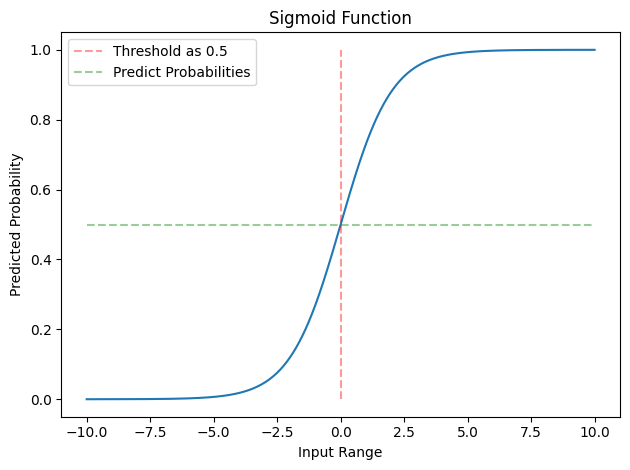

In [25]:
# plot the Sigmoid
sigmoid_rt = sigmoid_fn(l_list)

plt.plot(l_list, sigmoid_rt)
plt.vlines(x=0, ymin=0, ymax=1, colors='r', linestyles='--', alpha=0.4, label='Threshold as 0.5')
plt.hlines(y=0.5, xmin=-10, xmax=10, colors='g', linestyles='--', alpha=0.4, label='Predict Probabilities')
plt.xlabel('Input Range')
plt.ylabel('Predicted Probability')
plt.title('Sigmoid Function')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

#### 2) Tanh function

In [28]:
# define the tanh function
def tanh_fn(z):
    return (np.exp(z) - np.exp(-z)) / (np.exp(z) + np.exp(-z))

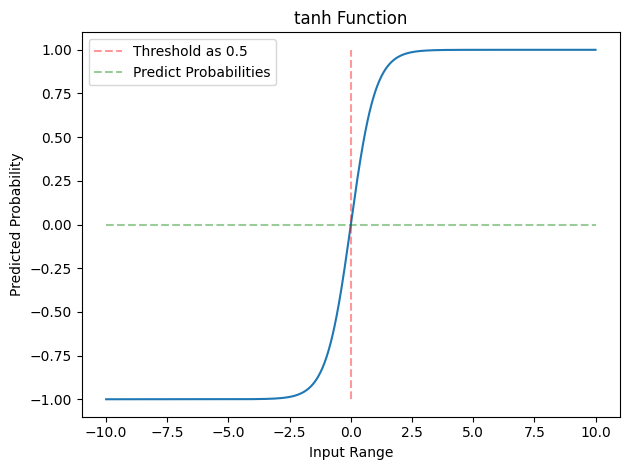

In [30]:
# plot the tanh function
tanh_rt = tanh_fn(l_list)

plt.plot(l_list, tanh_rt)
plt.vlines(x=0, ymin=-1, ymax=1, colors='r', linestyles='--', alpha=0.4, label='Threshold as 0.5')
plt.hlines(y=0, xmin=-10, xmax=10, colors='g', linestyles='--', alpha=0.4, label='Predict Probabilities')
plt.xlabel('Input Range')
plt.ylabel('Predicted Probability')
plt.title('tanh Function')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

#### 3) ReLu function

In [31]:
# defin Relu function
def ReLu(z):
    rt = np.where(z<=0, 0, z)
    return rt

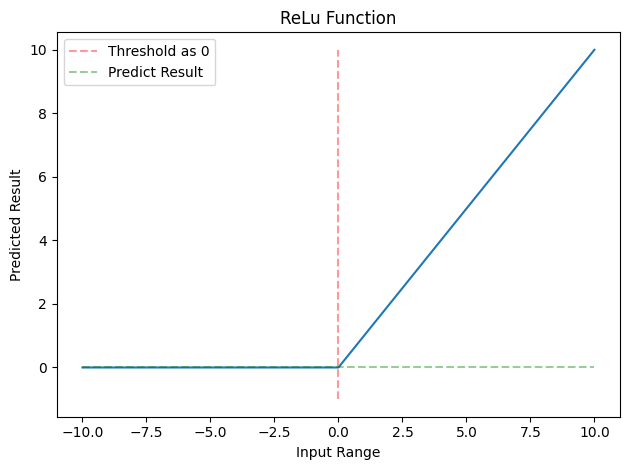

In [38]:
relu_rt = ReLu(l_list)

plt.plot(l_list, relu_rt)
plt.vlines(x=0, ymin=-1, ymax=10, colors='r', linestyles='--', alpha=0.4, label='Threshold as 0')
plt.hlines(y=0, xmin=-10, xmax=10, colors='g', linestyles='--', alpha=0.4, label='Predict Result')
plt.xlabel('Input Range')
plt.ylabel('Predicted Result')
plt.title('ReLu Function')
plt.legend(loc='best')
plt.tight_layout()
plt.show()